# DOBE-DOBE Unified Experiment Plot & Table Generator Notebook

This notebook consolidates all experiment visualization and metrics table rendering for the DOBE-DOBE project.
- **Aspect Ratio**: Ultra-flat & wide layout for crisp paper presentation.
- **Typography**: Times New Roman font with CJK fallback support.
- **Tables**: Interactive Pandas DataFrame rendering directly inside Jupyter Notebook cells.

In [ ]:
import os
import sys
import math
import csv
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from IPython.display import display

# Global Matplotlib Configuration
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['font.serif'] = ['Times New Roman', 'Microsoft JhengHei', 'SimSun', 'DejaVu Serif']
plt.rcParams['axes.unicode_minus'] = False

EXP_DIR = os.getcwd()
print(f'Notebook Root Directory: {EXP_DIR}')


## 0.1 POI Category Percentage Distribution

Folder: `0.1_poi_raido`

In [ ]:
import textwrap

out_dir = os.path.join(EXP_DIR, '0.1_poi_raido')
df = pd.read_csv(os.path.join(out_dir, 'data.csv'), index_col='category')

# 增大圖表尺寸與垂直空間，讓多行標籤有足夠的行距 (line spacing)
fig, ax = plt.subplots(figsize=(6.5, 4.8))

# 增加 width 讓字可以長一點再換行，減少擠壓
categories = [
    '\n'.join(textwrap.wrap(cat, width=22)) for cat in df.index[::-1]
]
ratios = df['ratio'][::-1]
counts = df['count'][::-1]

colors = plt.cm.plasma(pd.Series(range(len(categories))) / (len(categories) * 1.2))
bars = ax.barh(categories, ratios, color=colors, edgecolor='none', height=0.55)

ax.set_xlabel(
    'Percentage (%)', fontsize=12, fontweight='bold', fontfamily='Times New Roman'
)
ax.set_ylabel(
    'POI Category', fontsize=12, fontweight='bold', fontfamily='Times New Roman'
)
ax.set_title(
    'POI Category Distribution Percentage',
    fontsize=14,
    fontweight='bold',
    fontfamily='Times New Roman',
    pad=15,
)

# 調整 Y 軸文字的行高 (line_spacing) 與對齊方式，解決重疊問題
ax.tick_params(axis='both', which='major', labelsize=9.5)
for label in ax.get_yticklabels():
  label.set_linespacing(
      1.3
  )  # 增加行高間距，避免文字黏在一起 (例如 Business and Professional Services)

for bar, ratio, count in zip(bars, ratios, counts):
  ax.text(
      bar.get_width() + 0.5,
      bar.get_y() + bar.get_height() / 2,
      f'{ratio:.1f}% ({count:,})',
      va='center',
      fontsize=12,
      fontfamily='Times New Roman',
      color='#333333',
  )

ax.set_xlim(0, max(ratios) * 1.4)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
out_path = os.path.join(out_dir, '0.1_poi_raido.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

## 0.2 POI Spatial Distribution

Folder: `0.2_spatial_distrib`

In [ ]:
out_dir = os.path.join(EXP_DIR, '0.2_spatial_distrib')
df = pd.read_csv(os.path.join(out_dir, 'data.csv'))

categories = df['category'].unique()
cmap = plt.cm.get_cmap('tab10', len(categories))

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, cat in enumerate(categories):
    sub = df[df['category'] == cat]
    ax.scatter(sub['lon'], sub['lat'], s=1.5, color=cmap(i), alpha=0.6, label=cat, rasterized=True)

ax.set_xlabel('Longitude', fontsize=12, fontfamily='Times New Roman')
ax.set_ylabel('Latitude', fontsize=12, fontfamily='Times New Roman')
ax.set_title('POI Spatial Distribution', fontsize=14, fontweight='bold', fontfamily='Times New Roman', pad=10)

ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

ncol = math.ceil(len(categories) / 4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=ncol, fontsize=12, frameon=True, markerscale=4)

plt.tight_layout()
out_path = os.path.join(out_dir, '0.2_spatial.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textwrap

# 1. 讀取資料
out_dir_1 = os.path.join(EXP_DIR, "0.1_poi_raido")
df_bar = pd.read_csv(
    os.path.join(out_dir_1, "data.csv"), index_col="category"
)

out_dir_2 = os.path.join(EXP_DIR, "0.2_spatial_distrib")
df_scatter = pd.read_csv(os.path.join(out_dir_2, "data.csv"))

# ==================== 處理 "Others" 合併邏輯 ====================
df_bar = df_bar.sort_values(by="ratio", ascending=False)

if len(df_bar) > 4:
  top_df = df_bar.iloc[:-4]
  others_df = df_bar.iloc[-4:]

  other_ratio = others_df["ratio"].sum()
  other_count = others_df["count"].sum()

  new_row = pd.DataFrame(
      {"ratio": [other_ratio], "count": [other_count]}, index=["Others"]
  )
  df_bar_merged = pd.concat([top_df, new_row])

  other_categories = others_df.index.tolist()
  df_scatter_merged = df_scatter.copy()
  df_scatter_merged.loc[
      df_scatter_merged["category"].isin(other_categories), "category"
  ] = "Others"
else:
  df_bar_merged = df_bar.copy()
  df_scatter_merged = df_scatter.copy()

categories = df_bar_merged.index.tolist()

# 2. 指定美觀色彩（紅、藍、綠、粉、橘、棕等，Others 為灰）
color_palette = [
    "#1f77b4",  # 藍
    "#ff7f0e",  # 橘
    "#2ca02c",  # 綠
    "#d62728",  # 紅
    "#e377c2",  # 粉
    "#8c564b",  # 棕
    "#9467bd",  # 紫
    "#bcbd22",  # 黃綠
]

cat_to_color = {}
non_other_cats = [c for c in categories if c != "Others"]
for i, cat in enumerate(non_other_cats):
  cat_to_color[cat] = color_palette[i % len(color_palette)]
if "Others" in categories:
  cat_to_color["Others"] = "#999999"  # 灰

# 3. 建立畫布 figsize=(7, 3)，左圖比例 45%、右圖 55%
fig = plt.figure(figsize=(7, 3))
gs = fig.add_gridspec(1, 2, width_ratios=[0.45, 0.55], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# ==================== 左圖：POI Category Distribution ====================
categories_rev = categories[::-1]
ratios = df_bar_merged["ratio"].reindex(categories_rev)
bar_colors = [cat_to_color[cat] for cat in categories_rev]

# 【修改】：左圖完全不放 POI category 類別名稱字串
bars = ax1.barh(
    range(len(categories_rev)),
    ratios,
    color=bar_colors,
    edgecolor="none",
    height=0.55,
)

ax1.set_yticks(range(len(categories_rev)))
ax1.set_yticklabels([])  # 移除 Y 軸文字
ax1.tick_params(axis="y", length=0)

ax1.set_xlabel(
    "Percentage (%)", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
)
ax1.set_ylabel(
    "POI Category", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
)
ax1.set_title(
    "(a) POI Category Distribution",
    fontsize=12,
    fontweight="bold",
    fontfamily="Times New Roman",
    pad=8,
)

ax1.tick_params(axis="x", which="major", labelsize=12)

# 僅顯示百分比
for bar, ratio in zip(bars, ratios):
  ax1.text(
      bar.get_width() + 0.8,
      bar.get_y() + bar.get_height() / 2,
      f"{ratio:.1f}%",
      va="center",
      fontsize=12,
      fontweight="normal",
      fontfamily="Times New Roman",
      color="#333333",
  )

ax1.set_xlim(0, max(ratios) * 1.35)
ax1.grid(axis="x", linestyle="--", alpha=0.3)
ax1.set_axisbelow(True)

# ==================== 右圖：POI Spatial Distribution ====================
# 疊圖順序：Others 底層 (z=1)，其他類別上層 (z=2)
plot_categories = [c for c in categories if c != "Others"]
if "Others" in categories:
  plot_categories = ["Others"] + plot_categories

for cat in plot_categories:
  sub = df_scatter_merged[df_scatter_merged["category"] == cat]
  z = 1 if cat == "Others" else 2
  ax2.scatter(
      sub["lon"],
      sub["lat"],
      s=1.0,
      color=cat_to_color[cat],
      alpha=0.6,
      label=cat,
      zorder=z,
      rasterized=True,
  )

ax2.set_xlabel(
    "Longitude", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
)
ax2.set_ylabel(
    "Latitude", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
)
ax2.set_title(
    "(b) POI Spatial Distribution",
    fontsize=12,
    fontweight="bold",
    fontfamily="Times New Roman",
    pad=8,
)

ax2.tick_params(axis="both", which="major", labelsize=8)

ax2.grid(True, linestyle="--", alpha=0.3)
ax2.set_aspect("equal", adjustable="datalim")
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
# ==================== 共用下方圖例 (Shared Legend with Nextline) ====================
# 【修改】：對 legend 內的標籤項目進行自動換行 (Nextline wrapping)
wrapped_legend_labels = [
    "\n".join(textwrap.wrap(cat, width=20)) for cat in categories
]

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[cat],
        markersize=6,
    )
    for cat in categories
]

fig.legend(
    handles,
    wrapped_legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.44),
    ncol=3,  # 3 欄整齊換行排列
    fontsize=12,
    frameon=True,
    markerscale=1.2,
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
out_path = os.path.join('./', "poi_combined_analysis.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

## 0.3 Model Input Cosine Similarity Distribution

Folder: `0.3_input_similarity`

In [ ]:
out_dir = os.path.join(EXP_DIR, '0.3_input_similarity')
sim_dist = np.loadtxt(os.path.join(out_dir, 'data.csv'), delimiter=',', skiprows=1)

fig, ax = plt.subplots(figsize=(12, 3.5))
weights = np.ones_like(sim_dist) / len(sim_dist)

n, bins, patches = ax.hist(sim_dist, bins=50, weights=weights, color='#4363d8', edgecolor='white', linewidth=0.5, alpha=0.85)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title('Model Input Cosine Similarity Distribution', fontsize=14, fontweight='bold', fontfamily='Times New Roman', pad=10)
ax.set_xlabel('Cosine Similarity', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')

ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
out_path = os.path.join(out_dir, '0.3_input_similarity.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()


## 1.1.1 Baseline Rebuild Summary Table & Metric Plot

Folder: `1.1.1_baseline_rebuild`

In [ ]:
out_dir = os.path.join(EXP_DIR, '1.1.1_baseline_rebuild')
metrics = ['mae', 'mse', 'wape', 'deviance']
model_names = {
    'pca': 'PCA',
    'ae': 'AE',
    'vae': 'VAE',
    'ddae_fsce_tfidf': 'DDAE+FSCE+TFIDF (Ours)'
}

data_dict = {}
for m in metrics:
    filepath = os.path.join(out_dir, f'{m}.csv')
    if os.path.exists(filepath):
        df_m = pd.read_csv(filepath, index_col='fold')
        data_dict[m.upper()] = df_m

# 1. Display Interactive Pandas DataFrame Table
rows = []
for model_key, model_display in model_names.items():
    row = {'Model': model_display}
    for metric_name in ['MAE', 'MSE', 'WAPE']:
        if metric_name in data_dict:
            df_m = data_dict[metric_name]
            mean_val = df_m.loc['mean', model_key]
            folds_val = df_m.loc[['fold1', 'fold2', 'fold3', 'fold4', 'fold5'], model_key].astype(float)
            std_val = folds_val.std()
            row[metric_name] = f'{mean_val:.4f} ± {std_val:.4f}'
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(out_dir, 'summary_table.csv'), index=False)
with open(os.path.join(out_dir, 'summary_table.md'), 'w', encoding='utf-8') as f:
    f.write(summary_df.to_markdown(index=False))

print('=== 1.1.1 Baseline Rebuild Performance Summary Table ===')
display(summary_df.style.set_caption('1.1.1 Baseline Rebuild Metrics (Mean ± Std)').hide(axis='index'))

# 2. Performance Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 3.6))
eval_metrics = ['MAE', 'MSE', 'WAPE']
x_indices = np.arange(len(eval_metrics))
bar_width = 0.16
colors = ['#888888', '#4363d8', '#f58231', '#2ea043']

for i, (model_key, model_display) in enumerate(model_names.items()):
    means = [float(data_dict[m].loc['mean', model_key]) for m in eval_metrics]
    rects = ax.bar(x_indices + i * bar_width, means, bar_width, label=model_display, color=colors[i], alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., h + 0.02, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8.5, fontfamily='Times New Roman')

ax.set_xlabel('Evaluation Metric', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Metric Value (Lower is Better)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('1.1.1 Baseline Rebuild Performance Comparison', fontsize=14, fontweight='bold', fontfamily='Times New Roman', pad=10)

ax.set_xticks(x_indices + bar_width * 1.5)
ax.set_xticklabels(eval_metrics, fontsize=11, fontfamily='Times New Roman')
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, max(float(data_dict['MSE'].loc['mean', 'pca']) * 1.15, 2.5))
ncol = math.ceil(len(model_names) / 2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=ncol, fontsize=9.5, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, '1.1.1_baseline_rebuild.png'), dpi=300, bbox_inches='tight')
plt.show()


## 1.2.1 Ablation Study Summary Table & Metric Plot

Folder: `1.2.1_ablation_rebuild`

In [ ]:
out_dir = os.path.join(EXP_DIR, '1.2.1_ablation_rebuild')
metrics = ['mae', 'mse', 'wape', 'deviance']
model_names = {
    'ddae_fsce_tfidf': 'DDAE+FSCE+TFIDF (Full)',
    'ddae_fsce': 'DDAE+FSCE',
    'ddae': 'DDAE',
    'ae_fsce_tfidf': 'AE+FSCE+TFIDF',
    'ae_fsce': 'AE+FSCE',
    'ae': 'AE'
}

data_dict = {}
for m in metrics:
    filepath = os.path.join(out_dir, f'{m}.csv')
    if os.path.exists(filepath):
        df_m = pd.read_csv(filepath, index_col='fold')
        data_dict[m.upper()] = df_m

# 1. Display Interactive Pandas DataFrame Table
rows = []
for model_key, model_display in model_names.items():
    row = {'Model': model_display}
    for metric_name in ['MAE', 'MSE', 'WAPE']:
        if metric_name in data_dict:
            df_m = data_dict[metric_name]
            mean_val = df_m.loc['mean', model_key]
            folds_val = df_m.loc[['fold1', 'fold2', 'fold3', 'fold4', 'fold5'], model_key].astype(float)
            std_val = folds_val.std()
            row[metric_name] = f'{mean_val:.4f} ± {std_val:.4f}'
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(out_dir, 'summary_table.csv'), index=False)
with open(os.path.join(out_dir, 'summary_table.md'), 'w', encoding='utf-8') as f:
    f.write(summary_df.to_markdown(index=False))

print('=== 1.2.1 Ablation Study Rebuild Performance Summary Table ===')
display(summary_df.style.set_caption('1.2.1 Ablation Study Metrics (Mean ± Std)').hide(axis='index'))

# 2. Performance Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 3.6))
eval_metrics = ['MAE', 'MSE', 'WAPE']
x_indices = np.arange(len(eval_metrics))
bar_width = 0.13
colors = plt.cm.Dark2(np.linspace(0, 1, len(model_names)))

for i, (model_key, model_display) in enumerate(model_names.items()):
    means = [float(data_dict[m].loc['mean', model_key]) for m in eval_metrics]
    rects = ax.bar(x_indices + i * bar_width, means, bar_width, label=model_display, color=colors[i], alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., h + 0.015, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontfamily='Times New Roman')

ax.set_xlabel('Evaluation Metric', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Metric Value (Lower is Better)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('1.2.1 Ablation Study Metric Comparison', fontsize=14, fontweight='bold', fontfamily='Times New Roman', pad=10)

ax.set_xticks(x_indices + bar_width * 2.5)
ax.set_xticklabels(eval_metrics, fontsize=11, fontfamily='Times New Roman')
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, max(float(data_dict['MSE'].loc['mean', 'ae_fsce_tfidf']) * 1.15, 2.0))
ncol = math.ceil(len(model_names) / 2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=ncol, fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, '1.2.1_ablation_rebuild.png'), dpi=300, bbox_inches='tight')
plt.show()


## 1.2.3 TF-IDF Preprocessing Latent Space Impact

Folder: `1.2.3_ablation_tfidf_latent`

In [ ]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

out_dir = os.path.join(EXP_DIR, "1.2.3_ablation_tfidf_latent")
df = pd.read_csv(os.path.join(out_dir, "data.csv"))

fig, axes = plt.subplots(1, 2, figsize=(7, 4.5))
cmap = plt.get_cmap("tab10")

# 找出所有的 cluster 類別
unique_clusters = sorted(
    list(
        set(df["cluster_before"].unique()).union(
            set(df["cluster_after"].unique())
        )
    )
)

# 繪製左右兩張子圖（內部不再呼叫 legend）
sub_configs = [
    (axes[0], df["cluster_before"], "Before TF-IDF: log1p(count)"),
    (axes[1], df["cluster_after"], "After TF-IDF"),
]

for ax, labels, title in sub_configs:
  for k, c in enumerate(unique_clusters):
    m = labels == c
    ax.scatter(
        df.loc[m, "z1"],
        df.loc[m, "z2"],
        s=6,
        color=cmap(k % 10),
        linewidths=0,
        alpha=0.75,
        label=f"Cluster {c}",
        rasterized=True,
    )
  # 標題 14 bold，軸標籤與 ticks 12
  ax.set_title(
      title, fontsize=14, fontfamily="Times New Roman", pad=8
  )
  ax.set_xlabel(
      "z1", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
  )
  ax.set_ylabel(
      "z2", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
  )
  ax.tick_params(labelsize=12)
  ax.grid(alpha=0.2, linestyle="--")
  ax.set_aspect("equal", adjustable="box")

# 統一在最下方建立「一個」共用 Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
    fontsize=12,

    frameon=True,
    markerscale=2.5,
)

fig.suptitle(
    "Latent Space Distribution Impact of TF-IDF Preprocessing",
    fontsize=14,
    fontweight="bold",
    fontfamily="Times New Roman",
    y=1.02,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(
    os.path.join(out_dir, "1.2.3_ablation_tfidf_latent.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 1.2.3 TF-IDF Preprocessing Silhouette Score

Folder: `1.2.3_ablation_tfidf_silhouette`

In [ ]:
out_dir = os.path.join(EXP_DIR, '1.2.3_ablation_tfidf_silhouette')
df = pd.read_csv(os.path.join(out_dir, 'data.csv'))

stage_map = {'處理前 (log1p)': 'Before (log1p)', '處理後 (TF-IDF)': 'After (TF-IDF)', '處理前': 'Before', '處理後': 'After'}
names = [stage_map.get(s, s) for s in df['stage'].tolist()]
vals = df['silhouette'].tolist()

fig, ax = plt.subplots(figsize=(4, 3.2))
colors = ['#5c6bc0', '#ff9800']
bars = ax.bar(names, vals, color=colors[:len(names)], alpha=0.9, width=0.35)

pad = 0.03 * max(abs(v) for v in vals) if vals else 0.01
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + (pad if v >= 0 else -pad),
            f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top',
            fontsize=12, fontweight='bold', fontfamily='Times New Roman')

ax.axhline(0, color='black', linewidth=0.8)
ax.margins(y=0.25)
ax.set_xlabel('Processing Stage', fontsize=13, fontfamily='Times New Roman')
ax.set_ylabel('Silhouette Score', fontsize=13, fontfamily='Times New Roman')
ax.set_title('Silhouette Score Comparison', fontsize=15, fontweight='bold', fontfamily='Times New Roman', pad=10)

ax.tick_params(axis='both', which='major', labelsize=11)
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, '1.2.3_ablation_tfidf_silhouette.png'), dpi=300, bbox_inches='tight')
plt.show()


## 2.1.1 Latent Trajectory Shift Visualizations

Folder: `2.1.1_shift_visual`

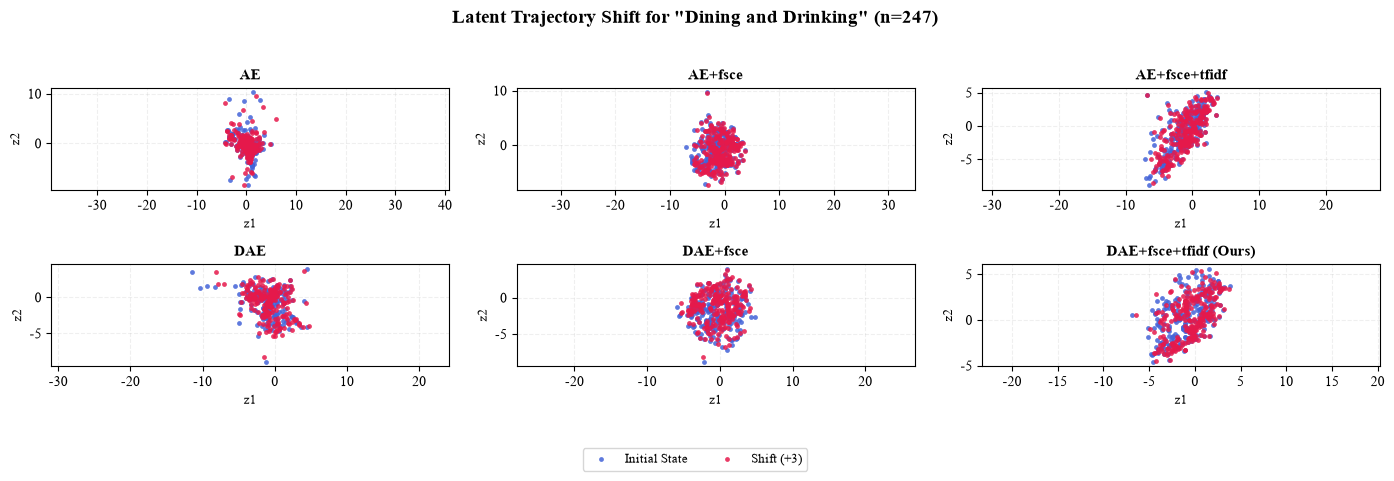

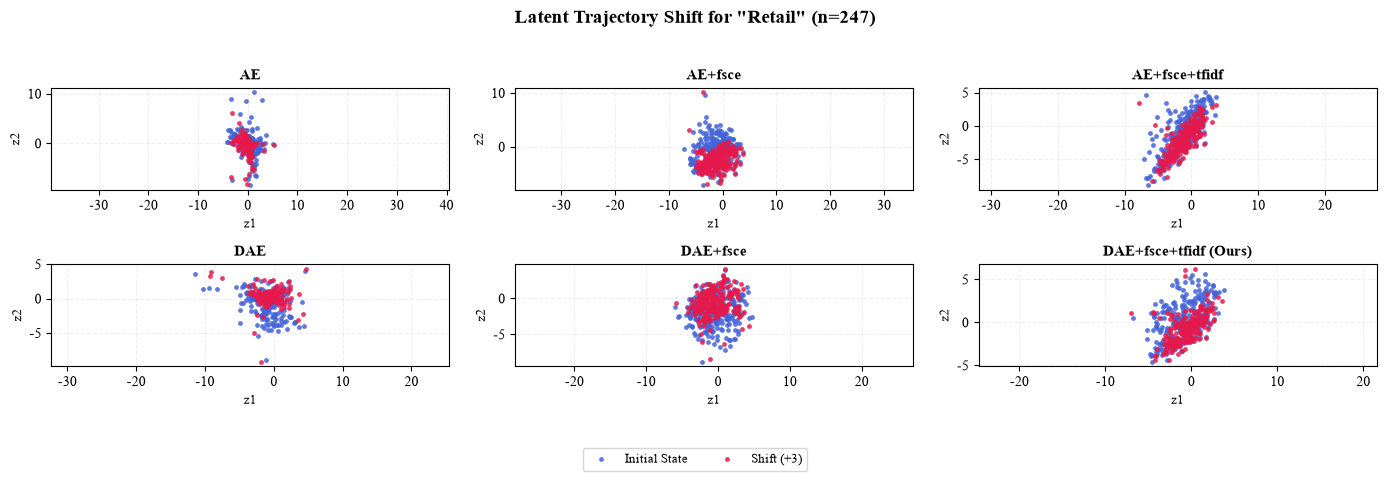

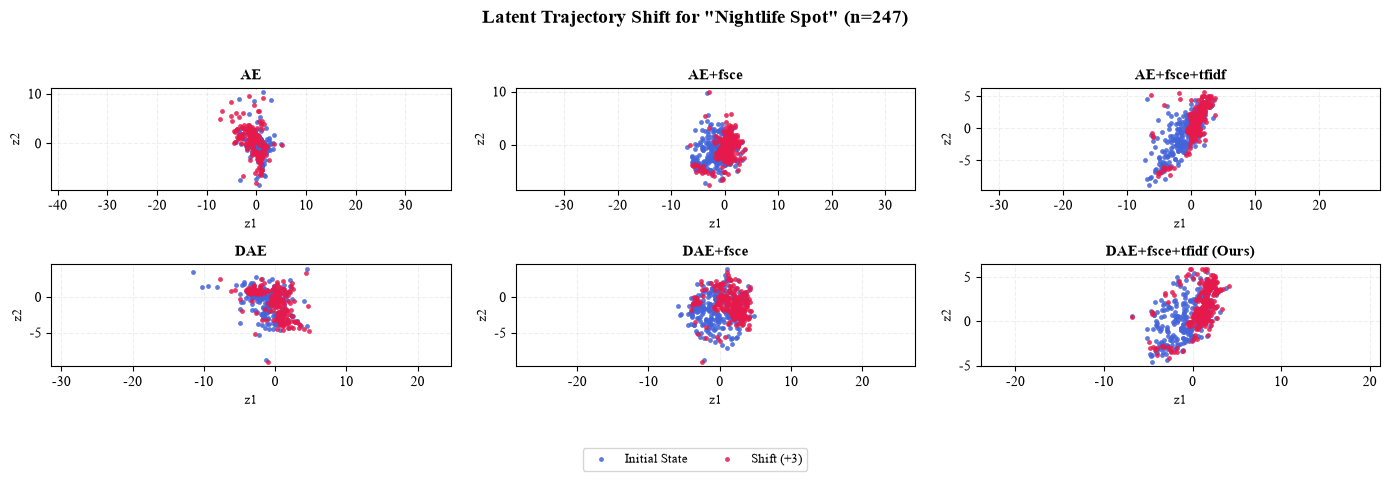

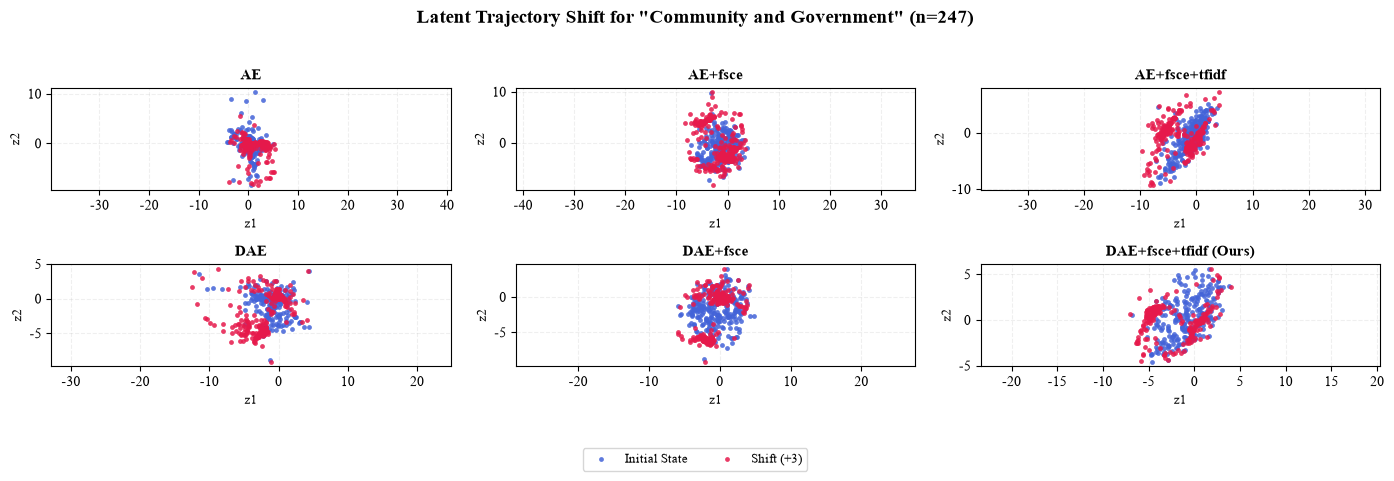

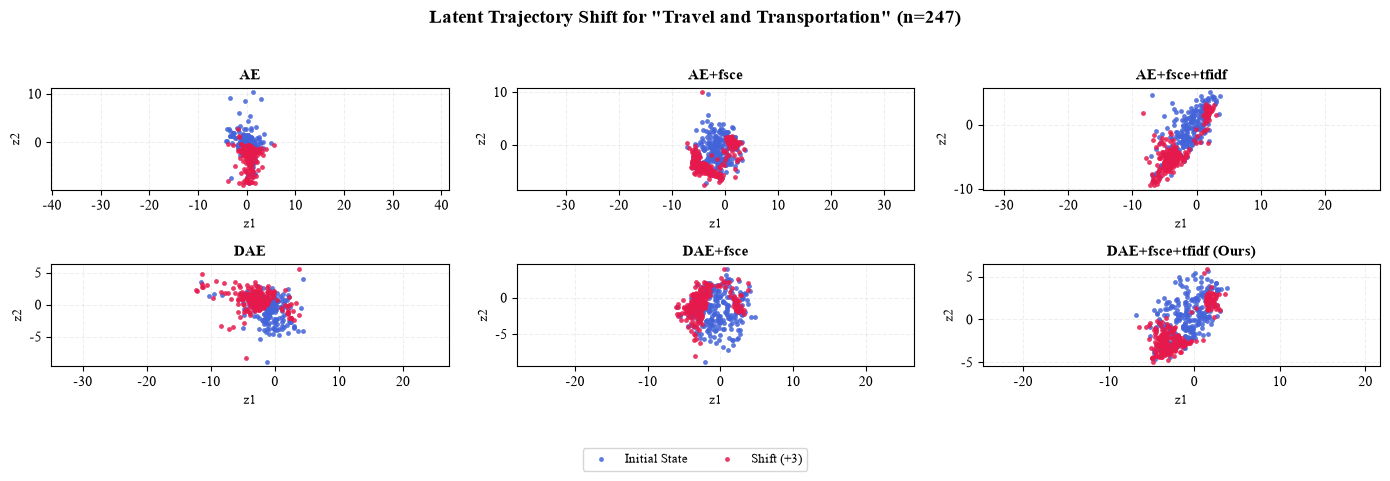

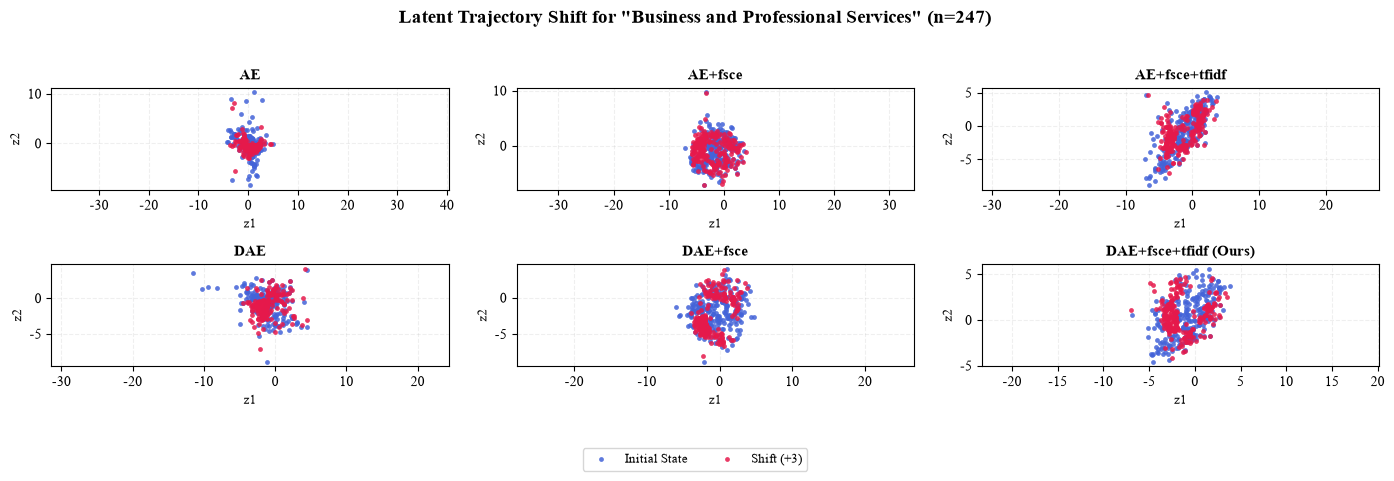

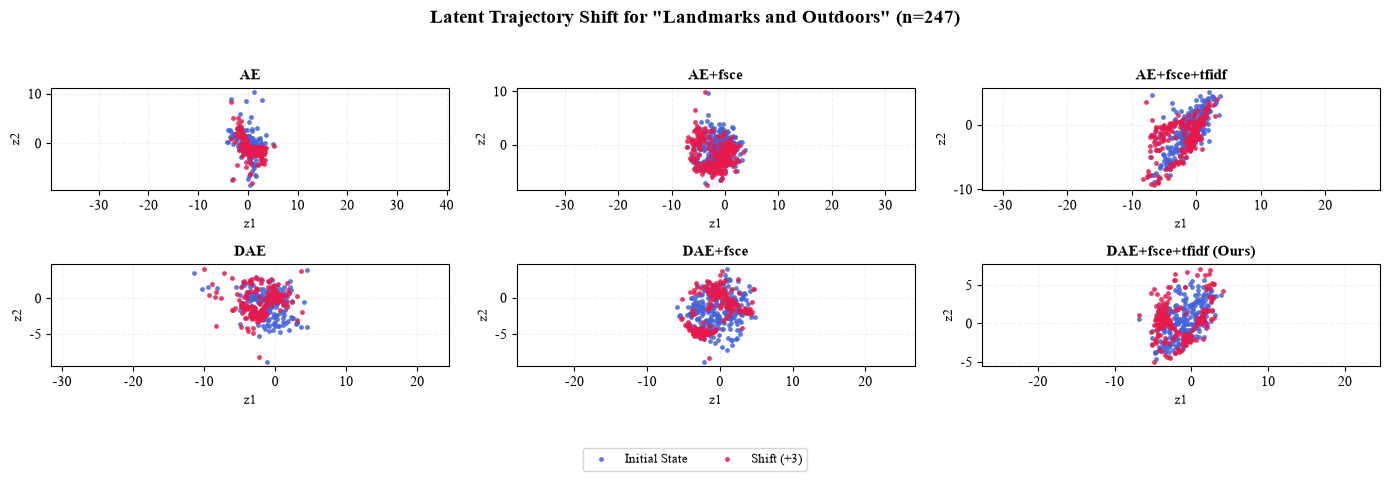

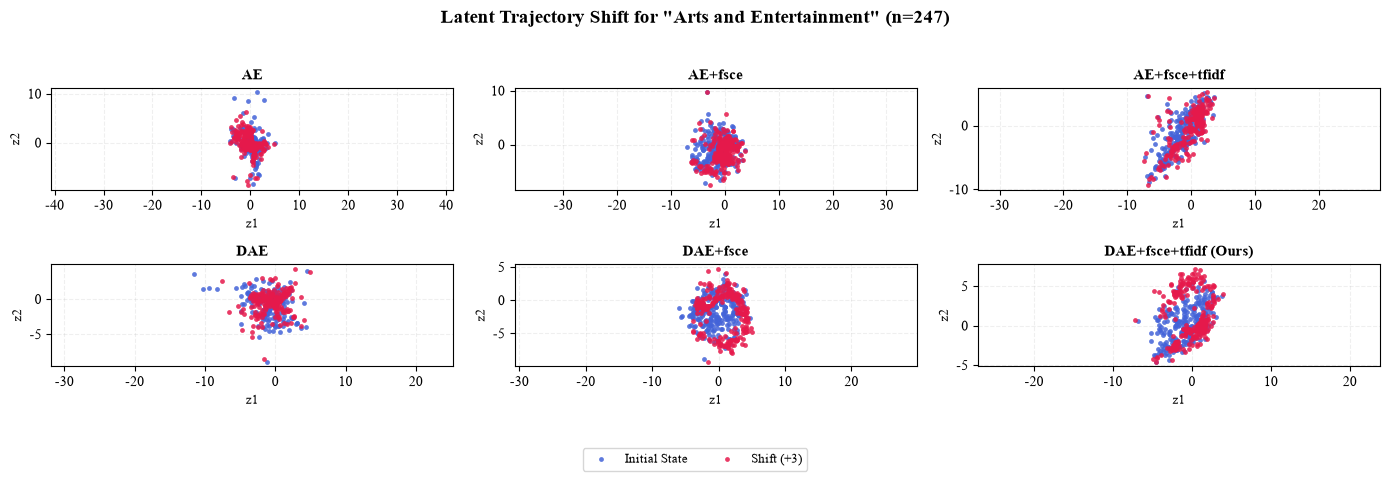

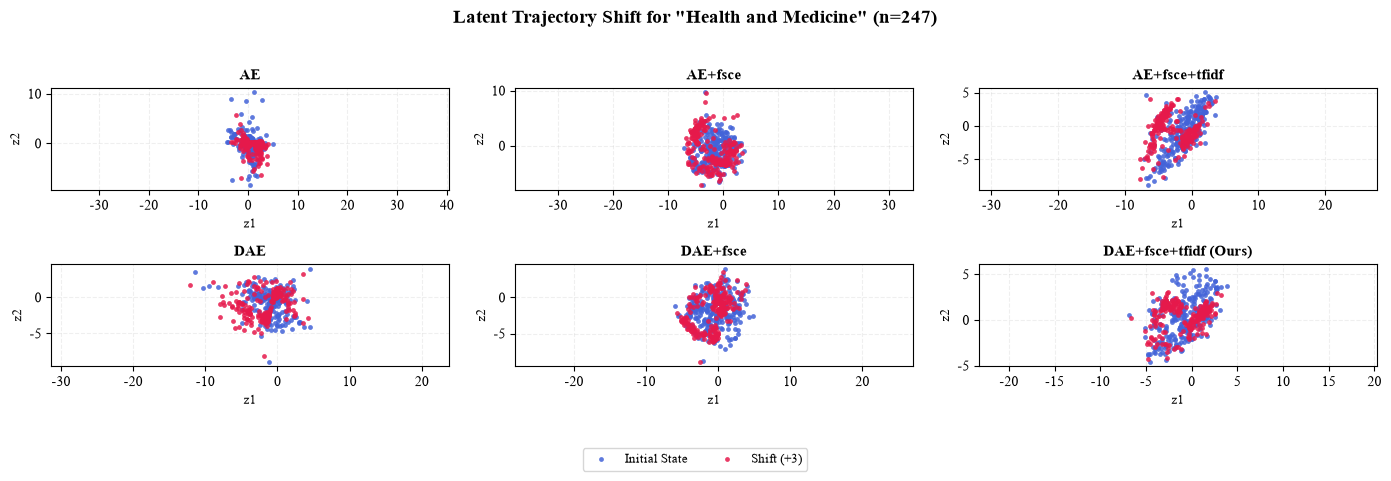

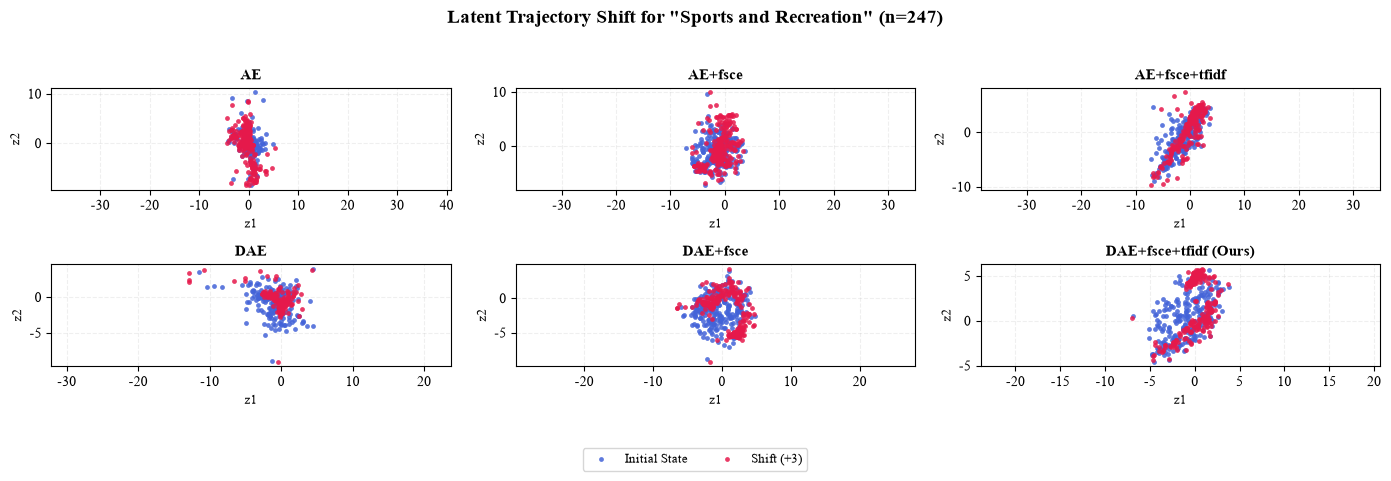

In [4]:
out_dir = os.path.join(EXP_DIR, '2.1.1_shift_visual')
PLOT_DIR = os.path.join(out_dir, 'latent_shift')
os.makedirs(PLOT_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(out_dir, 'data.csv'))
models = df['model'].unique().tolist()
categories = df['category'].unique().tolist()
max_step = df['step'].max()
max_amount = df.loc[df['step'] == max_step, 'amount'].iloc[0]

NCOLS = 3
COLOR_BEFORE = '#4363d8'
COLOR_AFTER = '#e6194b'
COLOR_MID = '#9e9e9e'

def draw_sub(ax, sub, title):
    for step in range(1, max_step):
        mid = sub[sub['step'] == step]
        ax.scatter(mid['z1'], mid['z2'], s=4, color=COLOR_MID, alpha=0.8, linewidths=0, zorder=10)
    before = sub[sub['step'] == 0]
    after = sub[sub['step'] == max_step]
    ax.scatter(before['z1'], before['z2'], s=12, color=COLOR_BEFORE, alpha=0.85, linewidths=0, zorder=11, label='Initial State')
    ax.scatter(after['z1'], after['z2'], s=12, color=COLOR_AFTER, alpha=0.85, linewidths=0, zorder=12, label=f'Shift (+{max_amount})')
    ax.set_title(title, fontsize=11, fontweight='bold', fontfamily='Times New Roman')
    ax.set_xlabel('z1', fontsize=9.5, fontfamily='Times New Roman')
    ax.set_ylabel('z2', fontsize=9.5, fontfamily='Times New Roman')
    ax.grid(alpha=0.2, linestyle='--')
    ax.set_aspect('equal', adjustable='datalim')

nrows = (len(models) + NCOLS - 1) // NCOLS

for cat_idx, category in enumerate(categories):
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(14, 4), squeeze=False)
    cat_df = df[df['category'] == category]
    for ax, name in zip(axes.flat, models):
        draw_sub(ax, cat_df[cat_df['model'] == name], name)
    for ax in axes.flat[len(models):]:
        ax.axis('off')
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=9.5, frameon=True)
    n_sample = cat_df[(cat_df['model'] == models[0]) & (cat_df['step'] == 0)].shape[0]
    fig.suptitle(f'Latent Trajectory Shift for "{category}" (n={n_sample})', fontsize=14, fontweight='bold', fontfamily='Times New Roman', y=1.03)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'{cat_idx:02d}_{category.replace(" ", "_")}.png'), dpi=300, bbox_inches='tight')
    plt.show()


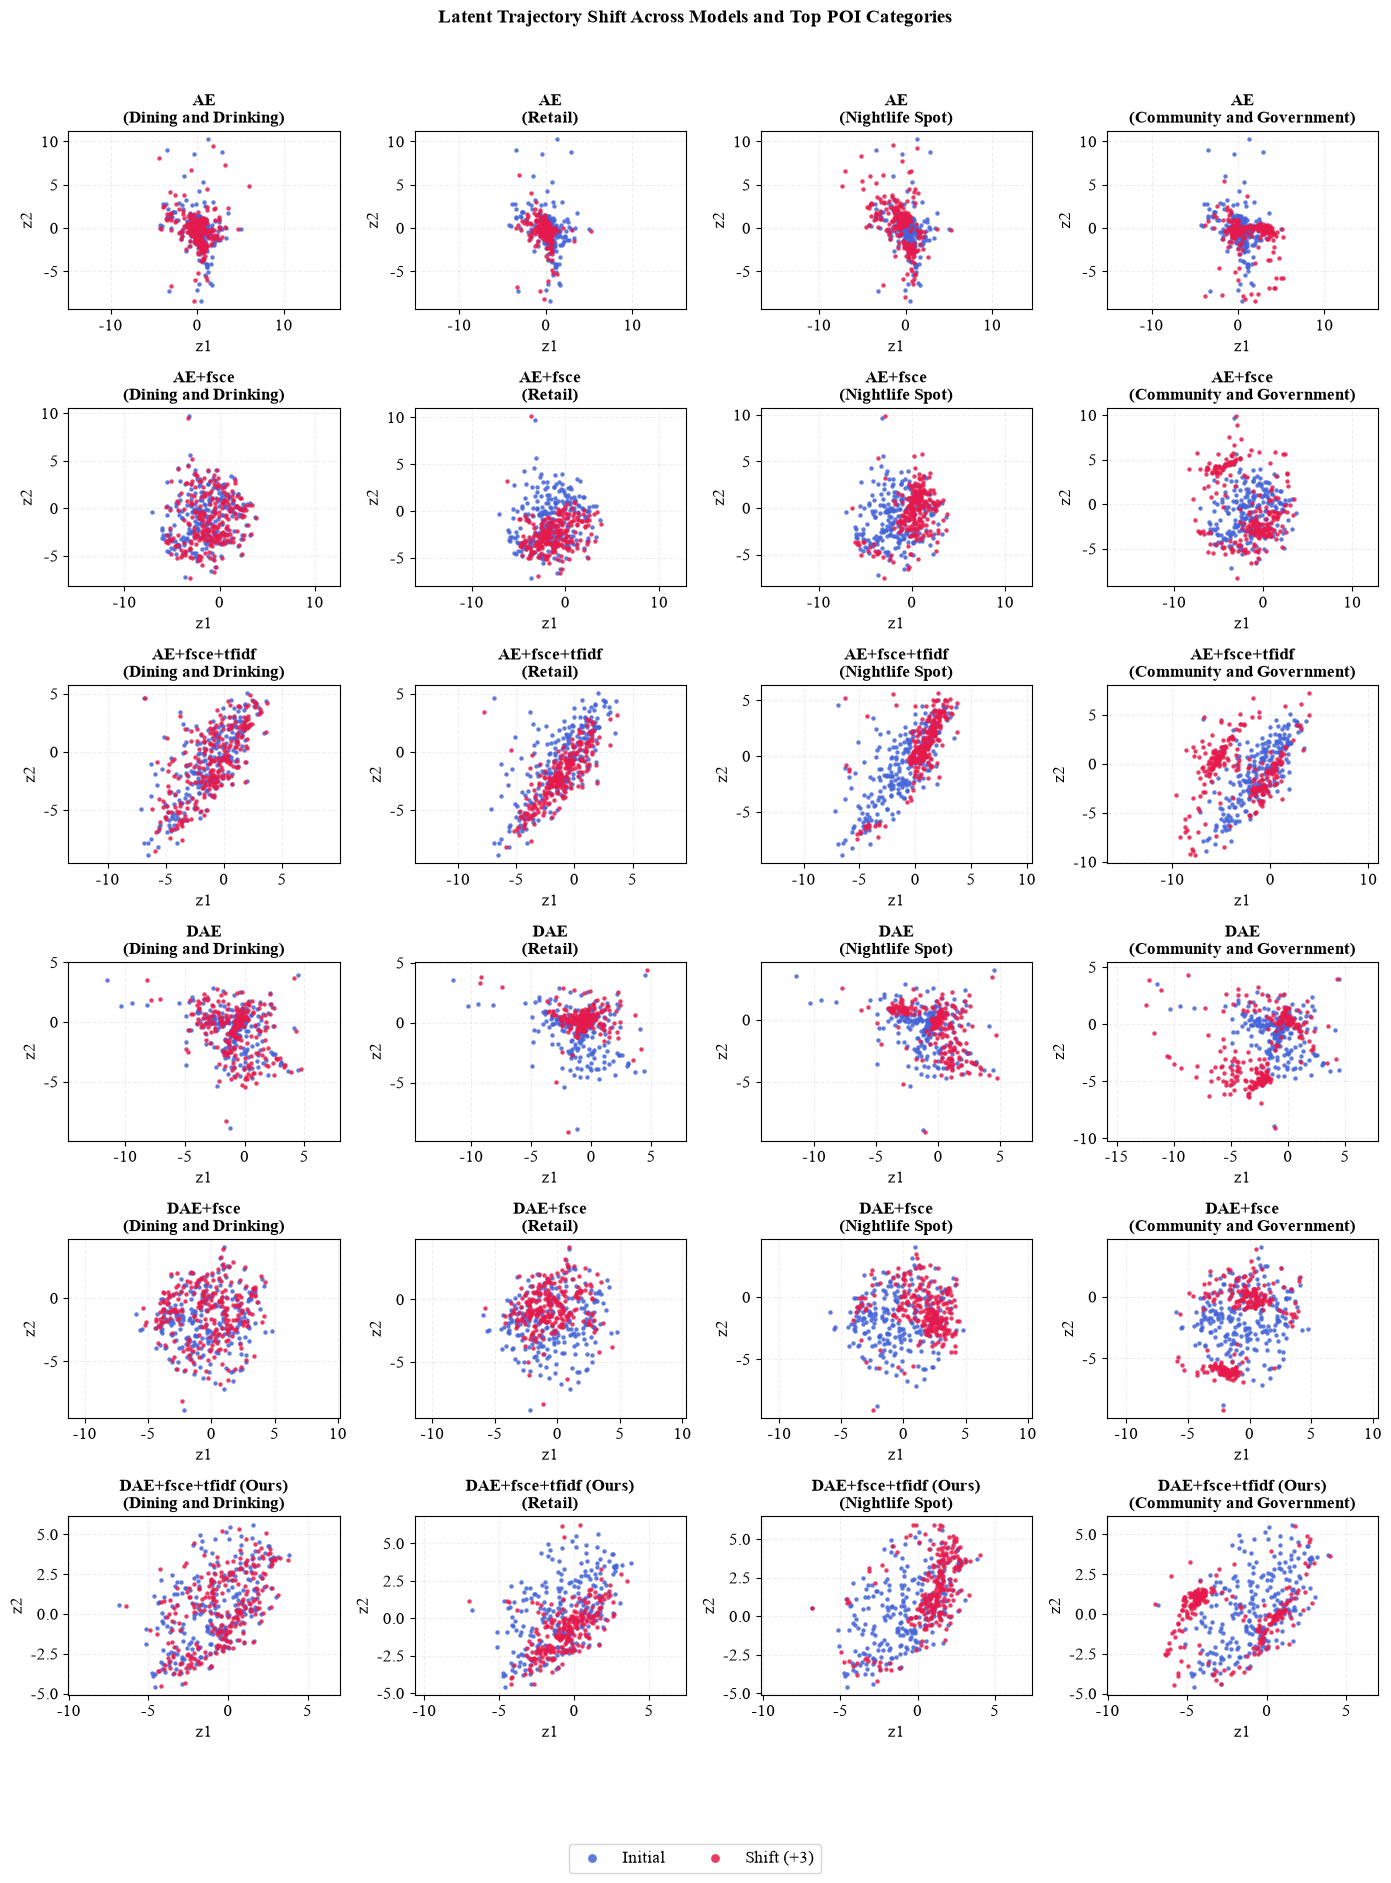

Summary matrix figure saved to: /Users/yentso/developer/StartOver/experiment/2.1.1_shift_visual/latent_shift_matrix_summary.png


In [5]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

out_dir = os.path.join(EXP_DIR, "2.1.1_shift_visual")
df = pd.read_csv(os.path.join(out_dir, "data.csv"))

models = df["model"].unique().tolist()
categories = df["category"].unique().tolist()
max_step = df["step"].max()
max_amount = df.loc[df["step"] == max_step, "amount"].iloc[0]

# 【策略 1 & 3 應用】：若 POI 太多，只取前 4 個最重要的高頻 POI，其餘合併或捨棄
# 這裡假設依資料筆數或指定清單篩選出 Top 4 POI
top_categories = df["category"].value_counts().head(4).index.tolist()
df_filtered = df[df["category"].isin(top_categories)]

COLOR_BEFORE = "#4363d8"
COLOR_AFTER = "#e6194b"
COLOR_MID = "#9e9e9e"

# 建立矩陣網格：Rows = Models, Columns = Top Categories
nrows = len(models)
ncols = len(top_categories)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows), squeeze=False)


def draw_sub(ax, sub, title):
  for step in range(1, max_step):
    mid = sub[sub["step"] == step]
    ax.scatter(
        mid["z1"],
        mid["z2"],
        s=3,
        color=COLOR_MID,
        alpha=0.7,
        linewidths=0,
        zorder=10,
    )
  before = sub[sub["step"] == 0]
  after = sub[sub["step"] == max_step]
  ax.scatter(
      before["z1"],
      before["z2"],
      s=10,
      color=COLOR_BEFORE,
      alpha=0.85,
      linewidths=0,
      zorder=11,
      label="Initial",
  )
  ax.scatter(
      after["z1"],
      after["z2"],
      s=10,
      color=COLOR_AFTER,
      alpha=0.85,
      linewidths=0,
      zorder=12,
      label=f"Shift (+{max_amount})",
  )
  ax.set_title(
      title, fontsize=12, fontweight="bold", fontfamily="Times New Roman"
  )
  ax.set_xlabel(
      "z1", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
  )
  ax.set_ylabel(
      "z2", fontsize=12, fontweight="normal", fontfamily="Times New Roman"
  )
  ax.tick_params(labelsize=12)
  ax.grid(alpha=0.2, linestyle="--")
  ax.set_aspect("equal", adjustable="datalim")


for r_idx, model_name in enumerate(models):
  for c_idx, cat_name in enumerate(top_categories):
    ax = axes[r_idx, c_idx]
    sub_df = df_filtered[
        (df_filtered["model"] == model_name)
        & (df_filtered["category"] == cat_name)
    ]
    draw_sub(ax, sub_df, f"{model_name}\n({cat_name})")

# 統一在最下方建立一個共用 Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=12,
    frameon=True,
    markerscale=2,
)

fig.suptitle(
    "Latent Trajectory Shift Across Models and Top POI Categories",
    fontsize=14,
    fontweight="bold",
    fontfamily="Times New Roman",
    y=1.02,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
out_path = os.path.join(out_dir, "latent_shift_matrix_summary.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Summary matrix figure saved to:", out_path)

## 2.1.2 AE+Entropy Training Progress Latent Clustering

Folder: `2.1.2_train_progress_entropy`

In [ ]:
out_dir = os.path.join(EXP_DIR, '2.1.2_train_progress_entropy')
df = pd.read_csv(os.path.join(out_dir, 'data.csv'))
percents = sorted(df['percent'].unique())
n_clusters = df['cluster'].nunique()
cmap = plt.get_cmap('tab10')

fig, axes = plt.subplots(1, len(percents), figsize=(14, 3.6), squeeze=False)

for ax, percent in zip(axes[0], percents):
    sub = df[df['percent'] == percent]
    for k in sorted(sub['cluster'].unique()):
        m = sub[sub['cluster'] == k]
        ax.scatter(m['z1'], m['z2'], s=8, color=cmap(k % 10), alpha=0.75, linewidths=0, label=f'Cluster {k}')
    ax.set_title(f'Progress {percent}%', fontsize=11, fontweight='bold', fontfamily='Times New Roman')
    ax.set_xlabel('z1', fontsize=9.5, fontfamily='Times New Roman')
    ax.set_ylabel('z2', fontsize=9.5, fontfamily='Times New Roman')
    ax.grid(alpha=0.2, linestyle='--')
    ax.set_aspect('equal', adjustable='box')

handles, labels = axes[0][0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ncol = math.ceil(len(by_label) / 2)
fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=ncol, fontsize=9.5, frameon=True, markerscale=2.5)

n = df[df['percent'] == percents[0]].shape[0]
fig.suptitle(f'AE+Entropy Training Progress Latent Clustering (n={n})', fontsize=14, fontweight='bold', fontfamily='Times New Roman', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, '2.1.2_train_progress_entropy.png'), dpi=300, bbox_inches='tight')
plt.show()


## 2.1.2 AE+Entropy Neighbor Preservation Rate

Folder: `2.1.2_train_progress_np`

In [ ]:
out_dir = os.path.join(EXP_DIR, '2.1.2_train_progress_np')
df = pd.read_csv(os.path.join(out_dir, 'data.csv'))

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.plot(df['percent'], df['neighbor_preservation'], marker='o', markersize=6, linewidth=2, color='#4363d8', label='Neighbor Preservation Rate')

# for x, y in zip(df['percent'], df['neighbor_preservation']):
#     ax.text(x, y + 0.01, f'{y:.3f}', ha='center', va='bottom', fontsize=9, fontfamily='Times New Roman')

ax.set_xlabel('Training Progress (%)', fontsize=12, fontfamily='Times New Roman')
ax.set_ylabel('Neighbor Preservation Rate', fontsize=12, fontfamily='Times New Roman')
ax.set_title('Neighbor Preservation Across Training Stages', fontsize=14, fontweight='bold', fontfamily='Times New Roman', pad=10)

ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), fontsize=9.5, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, '2.1.2_train_progress_np.png'), dpi=300, bbox_inches='tight')
plt.show()
